In [128]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import glob
import random
import copy


In [129]:
import matplotlib.pyplot as plt

def show_32x32(img, title):
    """
    img: torch.Tensor or numpy array of shape (32, 32)
         values assumed in [0, 1]
    """
    # normalize to [0, 1]
    #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img, cmap="gray_r")  # gray_r flips: 1=black, 0=white
    plt.title(title)
    plt.axis('off')
    plt.show()


In [ ]:
def combineFiles(quantity, infolder, outfolder, inFeatures):
    # passed parameters are mutable in python (will be modified in function if not copied)
    inputFeatures = copy.deepcopy(inFeatures)
    if len(inFeatures) < 13:
        inputFeatures.append("FireMask")

    # List of all csv files in the specified folder)
    all_files = glob.glob(f"{infolder}/*.csv")  
    max = len(all_files)

    if quantity > max:
        print(f"Too many files requested, max {max}")
        return 0, NULL

    # shuold be able to mod this later to get train and test splits, for now just randomly selects 
    # quantity number of files from the folder
    rand_nums = random.sample(range(19), quantity)
    rand_files = [f"{infolder}/{n:02d}.csv" for n in rand_nums]

    combined_df = pd.DataFrame()
    for f in rand_files:
        curr = pd.read_csv(f)
        curr = curr[inputFeatures]
        combined_df = pd.concat([combined_df, curr])

    # Save to a single CSV
    combined_df.to_csv(f"{outfolder}/split{quantity:d}.csv", index=False)

    # return which files were chosen so those can be used for the run 
    return rand_files, f"{outfolder}/split{quantity}.csv"



In [131]:
def genFakeTarget(prevmask, hw):
    prevmask_r = prevmask.values.reshape(hw, hw, 1)
    faketarget = np.zeros((hw, hw, 1))
    ditr = np.nditer(prevmask_r, flags=['multi_index'])

    for elem in ditr:
        if elem==1:
            br = ditr.multi_index[0]
            bc = ditr.multi_index[1]
            faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)
            if (br - 1) >= 0: faketarget[br-1][bc][0] = 1.0     # [r-1][c]
            if (br + 1) < w: faketarget[br+1][bc][0] = 1.0      # [r][c-1]
            if (bc - 1) >= 0: faketarget[br][bc-1][0] = 1.0     # [r][c+1]
            if (bc + 1) < h: faketarget[br][bc+1][0] = 1.0      # [r+1][c]
            
    return faketarget

In [152]:
"""Randomly axis-align crop input and output image tensors.
Args:
    crop_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    desired_size: side length (square) to crop to.
    num_in_channels: number of channels in crop_img.
    num_out_channels: number of channels in output_img.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def random_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int, num_in_channels: int, num_out_channels: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order should be CWH (no batch dim yet!!)
    # concat first (over CHANNELS, axis=1) so that image and label will be cropped the same, then separate again
    combined = torch.cat([input_img, output_img], dim=0) # CHW ordering (channel = dim0) rather than HWC as in tf. dim same as axis
    cropTransform = transforms.RandomCrop(size=(desired_size, desired_size))
    combined = cropTransform(combined)
    
    # size CHW (channel first)
    input_img = combined[0:num_in_channels, :, :]
    output_img = combined[-num_out_channels:, :, :]

    return input_img, output_img
    
    
    
"""Center crops input and output image tensors.
Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def center_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order is CHW not HWC as in torch so 0=channel, 1=height, 2=width
    central_fraction = desired_size / input_img.shape[1]
    cropH = int(input_img.shape[1]*central_fraction)
    cropW = int(input_img.shape[2]*central_fraction)

    cropTransform = transforms.CenterCrop(size=(cropH, cropW))
    input_img = cropTransform(input_img)
    output_img = cropTransform(output_img)

    return input_img, output_img


def getNormStats(combinedfile):
    df = pd.read_csv(combinedfile)
    if "FireMask" in df.columns:
        df = df.drop('FireMask', axis=1)

    std = df.std(axis=0)
    mean = df.mean(axis=0)
    return mean, std
    



In [155]:
INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']
BATCH_SIZE=32


"""
Taking out clip and normalize/clip and scale inputs and just automatically normalizing all the data. 
Adding a variable for whether fake target data should be generated
Adding a variable for the combined file for the split for normalization 
"""
class FireDataset(Dataset):
    def __init__(self, file_paths:List[str], comb_file, data_size=64, crop_size=32, in_channels=12,  
                 random_crop=True, center_crop=False,
                 fake_target=False):
        
        self.file_paths = file_paths
        self.center_crop = center_crop
        self.random_crop = random_crop
        self.data_size = data_size
        self.crop_size = crop_size
        self.in_channels = in_channels
        self.comb_file = comb_file
        self.fake_target = fake_target

        # read in all samples at once: leave preprocessing to getitem() method
        self.in_images = []
        self.labels = []
        #self.base_dir = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\"
        for file in self.file_paths:
            #curr_file = self.base_dir + file
            df = pd.read_csv(file)

            if self.fake_target is True:
                target = genFakeTarget(df["PrevFireMask"], data_size)
            else:
                # can't just select the first column since they are not always in order
                target = df["FireMask"].astype(np.float32)
                target[target == -1] = 0.0 # replacing "ambiguous" placeholder with "no fire" val

            target = target.reshape(64, 64, 1)

            data = df.drop('FireMask', axis=1).astype(np.float32)
            data = data[INPUT_FEATURES] # sort features into consistent order
            mean, std = getNormStats(self.comb_file) # get mean and std from combined file of entered filepaths
            data_norm = (data - mean)/std

            data_norm = data.values.reshape(64, 64, 12)
            
            # permute to get in shape CHW. DONT unsqueeze for batch dim as that is added by DataLoader!!!!
            image = torch.tensor(data_norm, dtype=torch.float32).permute(2,0,1)
            self.in_images.append(image)

            label = torch.tensor(target, dtype=torch.float32).permute(2,0,1)
            self.labels.append(label)
 
   
    def __len__(self):
        return len(self.file_paths)
    

    def __getitem__(self, idx): # GETITEM RETURNS WITH SIZE CHW
        # in_images is already a list of tensors in the correct shape
        input_img = self.in_images[idx]
        output_img = self.labels[idx]

        if self.random_crop and self.center_crop:
            raise ValueError('Cannot have both random_crop and center_crop be True')

        if self.random_crop:
            input_img, output_img = random_crop_io(input_img, output_img, desired_size=self.crop_size, 
                                        num_in_channels=self.in_channels, num_out_channels=1)
        elif self.center_crop:
            input_img, output_img = center_crop_io(input_img, output_img, desired_size=self.crop_size)
            
        #print("input shape:", input_img.shape, " output shape:", output_img.shape )
        return input_img, output_img
        


In [158]:
split5files, s5_combFile = combineFiles(5, "../03DataVisualization/renamed-raw-csvs", "../03DataVisualization/combo-files-for-norm", INPUT_FEATURES)
split5_dataset = FireDataset(split5files, s5_combFile, random_crop=False, center_crop=False, fake_target=True)
split5_dataloader = DataLoader(split5_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(split5files)

['../03DataVisualization/renamed-raw-csvs/03.csv', '../03DataVisualization/renamed-raw-csvs/09.csv', '../03DataVisualization/renamed-raw-csvs/02.csv', '../03DataVisualization/renamed-raw-csvs/12.csv', '../03DataVisualization/renamed-raw-csvs/10.csv']


In [ ]:
# for testing: keep the same 5 sample set but shuffle when this section is run
split5_dataloader = DataLoader(split5_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [181]:
class CAutoencoder(nn.Module):
    def __init__(self, inChannels=12):
        super().__init__()

        """ encoder """
        # following input -> (conv, relu, pool) pattern
        self.enc_conv1 = nn.Conv2d(in_channels=inChannels, out_channels=32, kernel_size=3, stride=1, padding=1) # C_out=32, maintain spatial
        self.enc_mp1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by factor of 2, channels maintained
        self.enc_relu1 = nn.ReLU()
        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1) # C_out doubled, spatial maintained
        self.enc_mp2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by half, channels maintained
        self.enc_relu2 = nn.ReLU()
        # if input is (12x64x64), output should now be (64x16x16)
        # not flattening, keeping last spatial size in bottleneck
        

        """ decoder """
        self.dec_mup1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.dec_relu1 = nn.ReLU()

        self.dec_mup2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)
        self.dec_sig = nn.Sigmoid()
        # opposite of encoder but final out channels is 1
        

    def forward(self, x):
        x = self.enc_conv1(x)
        x, idx1 = self.enc_mp1(x)
        x = self.enc_relu1(x)

        x = self.enc_conv2(x)
        x, idx2 = self.enc_mp2(x)
        enc_out = self.enc_relu2(x)

        # unpooling have to be reversed to get spatials right
        y = self.dec_mup2(enc_out, idx2)
        y = self.dec_conv1(y)
        y = self.dec_relu1(y)

        y = self.dec_mup1(y, idx1)
        y = self.dec_conv2(y)
        dec_out = self.dec_sig(y)
        return dec_out

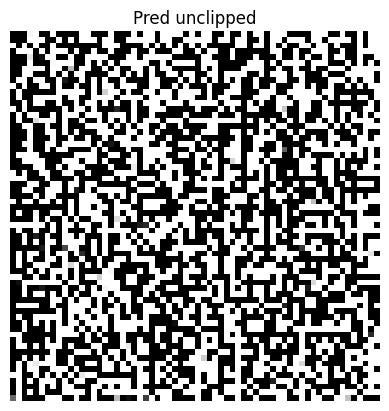

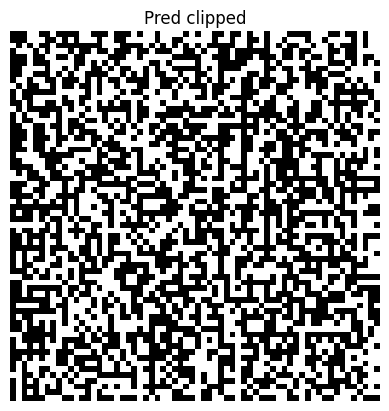

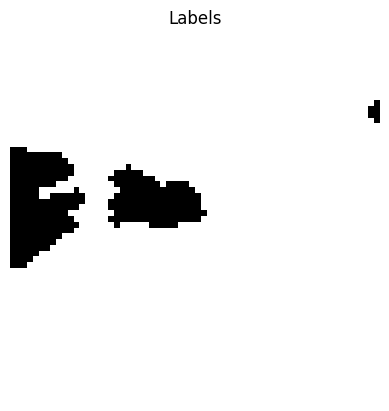

In [182]:
inputs, labels = next(iter(split5_dataloader))
model = CAutoencoder()
test_out = model(inputs)
out_clip = (test_out>=0.5).int()
show_32x32(test_out.detach().numpy()[0,0,:,:], "Pred unclipped")
show_32x32(out_clip.detach().numpy()[0,0,:,:], "Pred clipped")
show_32x32(labels[0,0,:,:], "Labels")